In [1]:
import pandas as pd
import os, json
from datetime import datetime
import matplotlib.pyplot as plt 
from matplotlib.cm import get_cmap
import numpy as np
import string
from utils import  get_codebook_object_from_json, convert_textdf_to_numeric_response_df

In [2]:
transcripts_dir = os.path.join(os.getcwd(), 'transcripts')
codebook_file = os.path.join(transcripts_dir, 'codebook.json')
with open(codebook_file, 'r') as file:
    codebook_json = json.load(file)
codebook = get_codebook_object_from_json(codebook_json)

In [3]:
gpt_res_dir = os.path.join(os.getcwd(),  'gpt-deductions')
transcripts_dir = os.path.join(os.getcwd(), 'transcripts')
errors_dir = os.path.join(os.getcwd(), 'gpterrors')
if not os.path.exists(errors_dir):
    os.makedirs(errors_dir)

In [4]:
def compute_accuracies(correct_df_text, predicted_df_text, pid):
    #file to save prediction errors
    errors_file = os.path.join(errors_dir, f"participant{pid}_errors.txt")
    accuracies = []
    code_to_accuracy = {}
    #convert text answers to correspondening numeric encodings
    correct_df            = convert_textdf_to_numeric_response_df(codebook, correct_df_text)
    predicted_df          = convert_textdf_to_numeric_response_df(codebook, predicted_df_text)
    #compute accuracies and save errors
    with open(errors_file, 'w') as file:
        for code in correct_df.keys():
            if  "Unnamed" in code: continue
            if code == 'PHYS11_TEMP':
                predicted_series = predicted_df[code].astype(float)
                actual_series    = correct_df[code].astype(float)
            else:
                predicted_series = predicted_df[code].astype(int)
                actual_series    = correct_df[code].astype(int)

            match = predicted_series == actual_series
            false_predictions    = predicted_df_text[code][~match]
            expected_predictions = correct_df_text[code][~match]
            
            for i, pred in false_predictions.items():
                print(f"Persona: {i+1} question: {code} predicted: {pred}  actual: {expected_predictions[i]}")
                file.write(f"Persona: {i+1} question: {code} predicted: {pred}  actual: {expected_predictions[i]}\n")
            accuracy = match.sum()/len(match)
            code_to_accuracy[code] = accuracy
            accuracies.append(accuracy)
            if len(false_predictions) > 0: print(code, accuracy)
            
    
    print(f"Average accuracy: {np.mean(accuracies)}")
    return code_to_accuracy

In [5]:
participant_ids = [i+1 for i in range(7)]
code_to_accuracies = {}
for pid in participant_ids:
    gpt_fname    = os.path.join(gpt_res_dir,     f"participant{pid}_deduced_2025-03-10.csv")
    survey_fname = os.path.join(transcripts_dir, f"participant{pid}/survey_responses.csv")
    correct_df_text       =  pd.read_csv(survey_fname).drop(columns=['Unnamed: 0'])
    predicted_df_text     =  pd.read_csv(gpt_fname)
    code_to_accuracy = compute_accuracies(correct_df_text, predicted_df_text, pid)
    for code in code_to_accuracy:
        if code not in code_to_accuracies: code_to_accuracies[code] = []
        code_to_accuracies[code].append(code_to_accuracy[code])


accuracy_df = pd.DataFrame(code_to_accuracies)
accuracy_df.head(8)   

1
response 2 for PHYS11_TEMP is nan assigning 404
response 3 for PHYS11_TEMP is nan assigning 404
response 2 for RACETH is nan assigning 404
response 1 for HH01S is nan assigning 404
response 1 for HH25S is nan assigning 404
response 1 for HH612S is nan assigning 404
response 1 for HH1317S is nan assigning 404
response 0 for SOC5A is 2, it is not in codebook, assigning 808
response 0 for SOC5B is 2, it is not in codebook, assigning 808
response 0 for SOC5C is 1, it is not in codebook, assigning 808
response 0 for SOC5D is 1, it is not in codebook, assigning 808
response 0 for SOC5E is 1, it is not in codebook, assigning 808
response 2 for PHYS11_TEMP is nan assigning 404
response 3 for PHYS11_TEMP is nan assigning 404
Persona: 4 question: AGE7 predicted: 35-44  actual: 45-54
AGE7 0.8
Persona: 3 question: RACETH predicted: nan  actual: REFUSED
RACETH 0.8
Persona: 2 question: HH01S predicted: nan  actual: 0
HH01S 0.8
Persona: 2 question: HH25S predicted: nan  actual: 0
HH25S 0.8
Persona:

,AGE7,GENDER,RACETH,HHINCOME,EDUCATION,HHSIZE1,HH01S,HH25S,HH612S,HH1317S,...,PHYS1C,PHYS1D,PHYS1E,PHYS1F,PHYS1G,PHYS1H,PHYS1I,PHYS1J,PHYS11,PHYS11_TEMP
0,0.8,1.0,0.8,1.0,1.0,1.0,0.8,0.8,0.8,0.8,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,1.0,1.0,0.8,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.8
2,1.0,0.8,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,1.0,1.0,1.0,1.0,0.8,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,0.8,1.0,1.0,1.0,1.0,1.0,1.0
4,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
5,0.8,1.0,1.0,1.0,1.0,1.0,0.8,0.8,0.8,0.8,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
6,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.8,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [6]:
avg_accuracies = accuracy_df.mean()
print(avg_accuracies)
avg_accuracies

AGE7           0.942857
GENDER         0.971429
RACETH         0.942857
HHINCOME       1.000000
EDUCATION      0.971429
HHSIZE1        1.000000
HH01S          0.942857
HH25S          0.942857
HH612S         0.942857
HH1317S        0.942857
HH18OVS        0.971429
SOC2A          0.942857
SOC2B          0.971429
SOC5A          0.942857
SOC5B          0.942857
SOC5C          0.971429
SOC5D          0.971429
SOC5E          0.942857
ECON1          0.942857
PHYS8          0.942857
PHYS4          1.000000
PHYS5          1.000000
PHYS1B         0.971429
PHYS1C         0.971429
PHYS1D         1.000000
PHYS1E         1.000000
PHYS1F         0.971429
PHYS1G         1.000000
PHYS1H         1.000000
PHYS1I         1.000000
PHYS1J         1.000000
PHYS11         1.000000
PHYS11_TEMP    0.971429
dtype: float64


AGE7           0.942857
GENDER         0.971429
RACETH         0.942857
HHINCOME       1.000000
EDUCATION      0.971429
HHSIZE1        1.000000
HH01S          0.942857
HH25S          0.942857
HH612S         0.942857
HH1317S        0.942857
HH18OVS        0.971429
SOC2A          0.942857
SOC2B          0.971429
SOC5A          0.942857
SOC5B          0.942857
SOC5C          0.971429
SOC5D          0.971429
SOC5E          0.942857
ECON1          0.942857
PHYS8          0.942857
PHYS4          1.000000
PHYS5          1.000000
PHYS1B         0.971429
PHYS1C         0.971429
PHYS1D         1.000000
PHYS1E         1.000000
PHYS1F         0.971429
PHYS1G         1.000000
PHYS1H         1.000000
PHYS1I         1.000000
PHYS1J         1.000000
PHYS11         1.000000
PHYS11_TEMP    0.971429
dtype: float64

/var/folders/0f/lqjqfrb16p5gf3__wqf2c94h1tfy6x/T/ipykernel_53548/2502222336.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap('Blues')


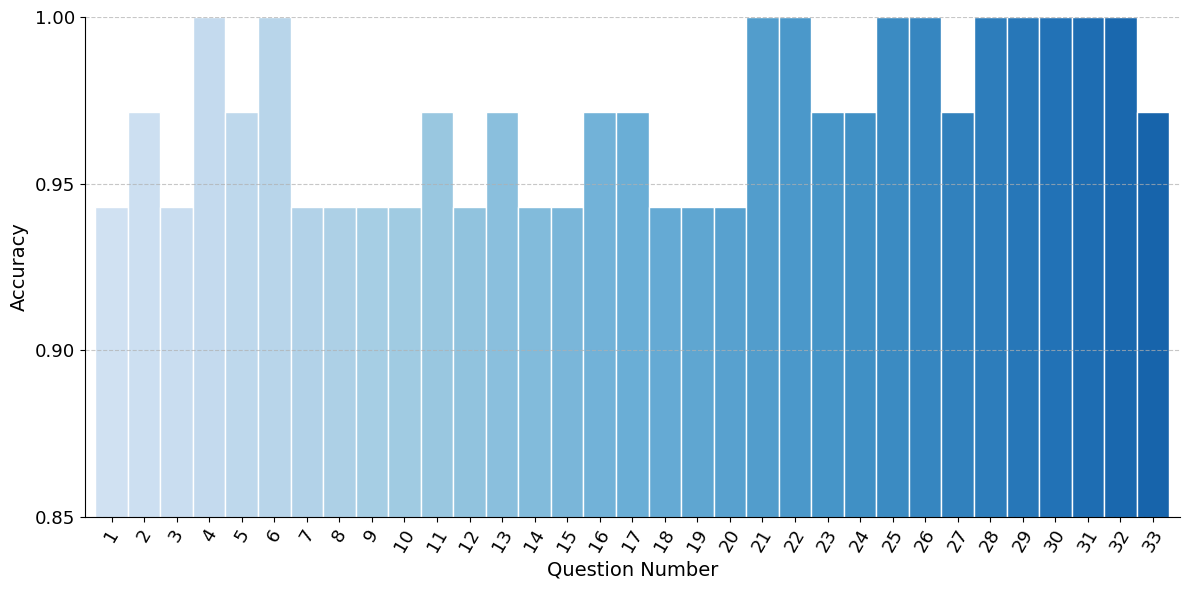

In [7]:
# Create figure and axis  
fig, ax = plt.subplots(figsize=(12, 6))   
x_values = range(1, len(avg_accuracies) + 1) 

  
#define color map
cmap = get_cmap('Blues')    
normalized_indices = np.linspace(0.2, 0.8, len(avg_accuracies))  
colors = cmap(normalized_indices) 


# Bar plot  
ax.bar(x_values, avg_accuracies, color=colors, width = 1, edgecolor='white')  
ax.margins(x=0.01) 
#ax.set_title('Accuracy vs question number', fontsize=12)  
ax.set_xlabel('Question Number', fontsize=14)  
ax.set_ylabel('Accuracy', fontsize=14)  
ax.set_xticks(x_values)  
ax.set_ylim([0.85, 1.0])
ax.set_yticks([0.85, 0.9, 0.95, 1.0])
ax.tick_params(axis='y', labelsize=13)
ax.tick_params(axis='x', labelsize=13, labelrotation=60) 
ax.grid(axis='y', linestyle='--', alpha=0.7)  

# Remove plot border lines (spines)  
ax.spines['top'].set_visible(False)   
ax.spines['right'].set_visible(False)    
#ax.spines['left'].set_visible(False)    

plt.tight_layout()  
plt.show() 
fig.savefig("gpt_accuracies.pdf")